# Prvi probni kolokvij

## 1. Zadatak (50)

Pred vama se nalazi skup podataka `os.csv` koji predstavlja meteorološki izvještaj na području Osijeka za razdoblje od `1.1.2025.` do `31.12.2025.` godine. Izvještaj obuhvaća različite meteorološke varijable koje opisuju dnevne vremenske uvjete, a dostupne značajke uključuju datum (`date`), prosječnu dnevnu temperaturu (`tavg`), minimalnu temperaturu (`tmin`), maksimalnu temperaturu (`tmax`), količinu oborina (`prcp`), količinu snijega (`snow`), smjer vjetra (`wdir`), brzinu vjetra (`wspd`), maksimalne udare vjetra (`wpgt`), tlak zraka (`pres`) te trajanje sunčeva zračenja (`tsun`).

**Vaši zadaci su sljedeći**:

1. **Rad s podacima(10 + 3 + 2 + 3)**:
    1. **Obvezni dio**: Učitajte podatke iz datoteke `os.csv` te provedite osnovnu analizu skupa podataka. Prikažite prvih nekoliko redaka podataka kako biste stekli uvid u strukturu i sadržaj skupa. Tijekom analize uočit ćete da neki podaci sadrže nedostajuće vrijednosti (`NaN`). Potrebno je iz originalnog skupa podataka ukloniti sve značajke koje nemaju definirane vrijednosti za svih `365` dana. 
    Također, iz skupa podataka uklonite značajku `date`. 

    2. **Dodatni dio**: Za dodatne bodove potrebno je detaljnije obraditi podatke i proširiti skup značajki. 
    
        1. Za jednu od značajki vidjet ćete da fali samo nekoliko podataka, pronađite indekse na kojima se pojavljuju `NaN` vrijednosti te te vrijednosti zamijenite s `0`, čime omogućujete korištenje te značajke u daljnjoj analizi. 
        
        **Hint: ovo možete uz pomoć `Pandas` funkcije `.fillna(value)` na odabranu značajku**.
    
        2. Osmislite način kako **uključiti datum** određenog dana u model.
    
        3. Definirajte novu značajku koja opisuje godišnje doba. Uzmite u obzir sljedeće početke godišnjih doba:
        - proljeće: `21.3.`
        - ljeto: `21.6.`
        - jesen: `21.9.`
        - zima: `21.12.`

        Na temelju tih datuma odredite odgovarajuće indekse te dodajte novu značajku u skup podataka na način koji smatrate prikladnim za daljnje modeliranje.

2. **Vizualizacija (5)**: 
    
    1. Vizualizirajte odabrane **značajke kroz vrijeme** koristeći podatke dobivene u obveznom dijelu prvog zadatka. Svaku značajku prikažite na zasebnom grafu. Svakom grafu dodajte odgovarajući naslov te legendu koja jasno označava koju značajku prikazujete.

3. **Odabir značajki za model i treniranje modela (5 + 4 + 3)**:

    Vrijednosti iz prethodnog dana često mogu pomoći u predviđanju vremena za sljedeći dan.
    
    1. Stoga kao ulazne podatke (**X**) koristite sve dane od prvog do predzadnjeg, dok kao izlaz (**y**) uzmite značajku `tavg` za dane od drugog do zadnjeg.

    2. Podatke **razdvojite** na skup za treniranje i testiranje u omjeru **80:20**. Budući da se radi o vremenskim podacima, pazite da funkcija za razdvajanje podataka **ne miješa podatke**, već da ih uzima redoslijedom.

    3. **Natrenirajte model**.

4. **Ocjene modela (3 + 5 + 2 + 5)**:

    1. Za svoj model koristite **adekvatne metrike** za ocjenu modela.

    2. **Ispišite parametre modela**. Također, **komentirajte** koji parametar iz X-a najviše utječe na predviđanje temperature.

    3. **Istražite metriku** koja pokazuje koliko model **prosječno apsolutno odstupa** od stvarne temperature. 

    4. **Nacrtajte predviđanje** modela i stvarne podatke na skupu za testiranje: stvarne podatke prikažite **zelenom bojom**, a predviđanje modela **plavom isprekidanom linijom** (-). 

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

In [5]:
df = pd.read_csv('os.csv')
df.head()
df = df.drop(columns='date')

df.isnull().sum()
df = df.drop(columns=['snow','wdir','tsun'])
df.isnull().sum()
df['prcp']=df['prcp'].fillna(0)
df.isnull().sum()


tavg    0
tmin    0
tmax    0
prcp    0
wspd    0
wpgt    0
pres    0
dtype: int64

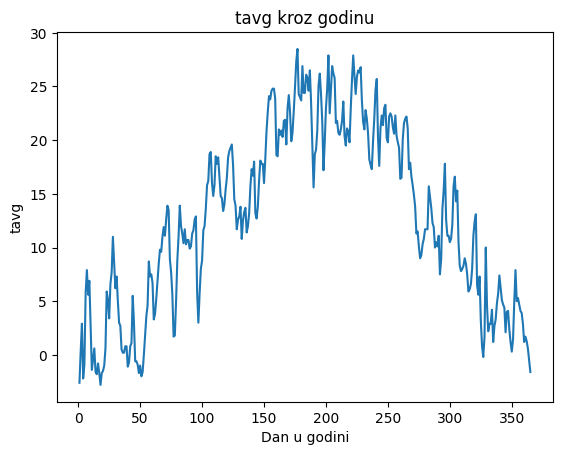

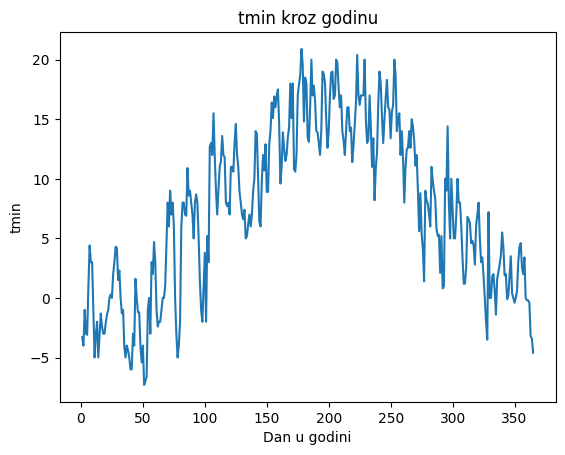

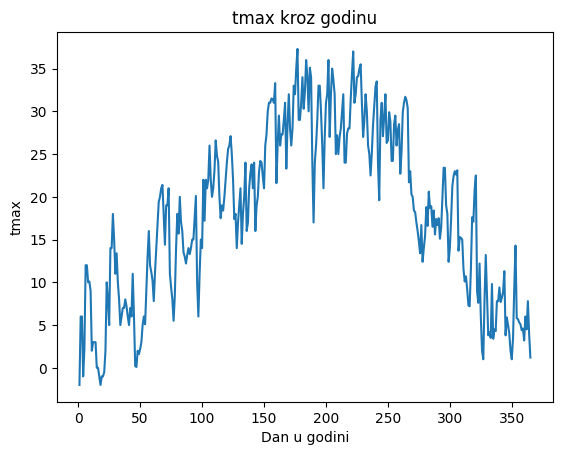

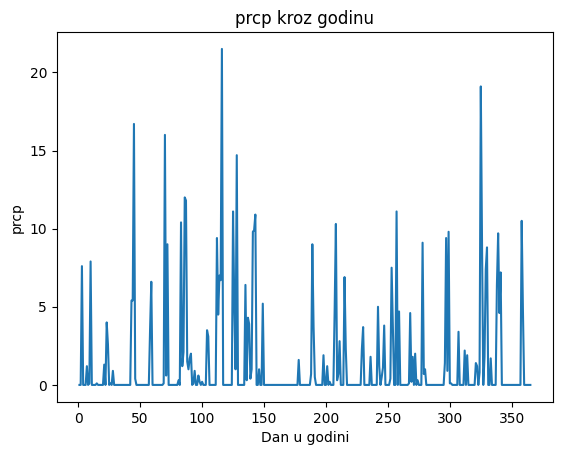

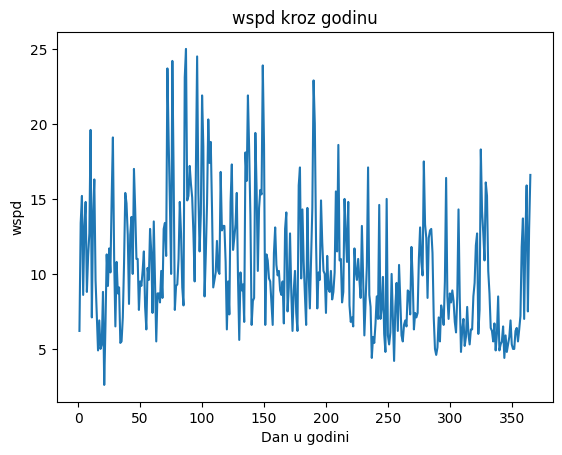

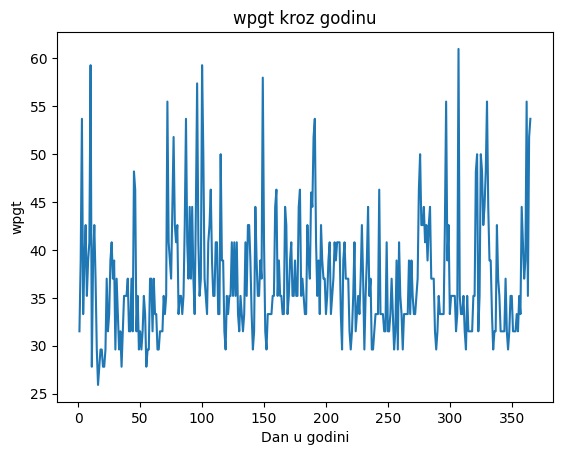

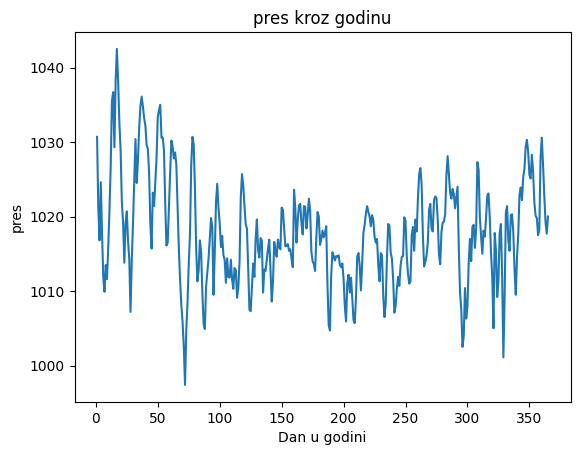

In [6]:
#vizualizacija znacajki kroz vrijeme
for col in df.columns:
    plt.plot(df.index+1, df[col])
    plt.xlabel('Dan u godini')
    plt.title(f'{col} kroz godinu')
    plt.ylabel(col)
    plt.show()

In [7]:
#Odabir znacajka za model i treniranje
X=df.iloc[:-1]
y=df['tavg'].iloc[1:]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42, shuffle=False)
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(mse,r2,mae)

4.560162283830176 0.7812487302153331 1.5361813470593348


Text(0.5, 1.0, 'Predviđanje prosječne vrijednosti')

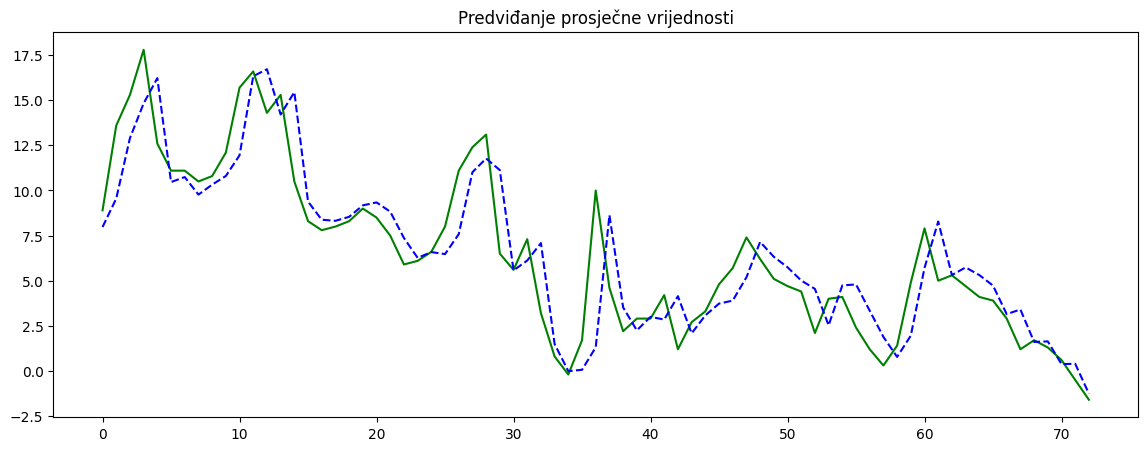

In [8]:
pd.Series(lr.coef_)
plt.figure(figsize=(14,5))
plt.plot(range(len(y_test)),y_test, color='green', label='Stvarne vrijednosti')
plt.plot(range(len(y_pred)),y_pred, color='blue', label='Predviđene vrijednosti', linestyle='--')
plt.title('Predviđanje prosječne vrijednosti')


# 2. Zadatak (50)

Pred vama se nalazi klasični **Iris** skup podataka koji sadrži mjerenja cvjetova perunike za tri vrste: *Iris setosa* (klasa 0), *Iris versicolor* (klasa 1) i *Iris virginica* (klasa 2). Svaki uzorak opisuju četiri značajke: duljina čašičnog listića (`sepal length`), širina čašičnog listića (`sepal width`), duljina latičnog listića (`petal length`) i širina latičnog listića (`petal width`).

**Vaši zadaci su sljedeći:**

1. **Rad s podacima (10 + 5)**:
    1. **Obvezni dio (10)**: Učitajte Iris skup podataka pomoću `sklearn.datasets.load_iris()`. Stvorite `DataFrame` s odgovarajućim imenima stupaca te dodajte stupac s oznakom klase. Provedite osnovnu analizu skupa podataka: prikažite prvih nekoliko redaka, strukturu i opis podataka. Ispišite koliko primjera pripada svakoj klasi te koji su nazivi klasa.

    2. **Dodatni dio (5)**: Vizualizirajte raspored podataka za najmanje **dva različita para značajki**. Komentirajte možete li vizualno zaključiti je li problem linearno separabilan.

2. **Predprocesiranje i osnovna klasifikacija (15 = 5 + 5 + 5)**:

    1. **(5)** Razdvojite podatke na skup za treniranje i testiranje u omjeru **80:20** te standardizirajte značajke.

    2. **(5)** Natrenirajte odgovarajući linearni klasifikator i ispišite **točnost** na testnom skupu.

        **Napomena:** Za izračun točnosti možete koristiti funkciju `accuracy_score(y_true, y_pred)` iz `sklearn.metrics`.

    3. **(5)** Prikažite **matricu zabune** na testnom skupu. Ručno izračunajte i ispišite **preciznost** i **odziv** za svaku klasu.

3. **Vlastita implementacija One-vs-One klasifikatora (20 = 10 + 10)**:

    Pristup **jedan-protiv-jednog (One-vs-One, OvO)** za $k$ klasa trenira $\dfrac{k(k-1)}{2}$ binarnih klasifikatora, po jedan za svaki mogući par klasa. Predikcija se određuje **glasanjem** svih klasifikatora, a pobjeđuje klasa s najviše glasova.

    1. **Treniranje (10)**: Implementirajte OvO treniranje koristeći binarni linearni klasifikator za svaki par klasa.

        **Napomena:** Za dohvaćanje jedinstvenih klasa iz niza oznaka možete koristiti `np.unique(y)`.

    2. **Predikcija i evaluacija (10)**: Implementirajte predikciju glasanjem te evaluirajte svoju implementaciju na testnom skupu te ispišite **točnost** i prikažite **matricu zabune**.

4. **Gotovi One-vs-One klasifikator (10 = 5 + 3 + 2)**:

    1. **(5)** Koristeći gotov `OneVsOneClassifier` iz `sklearn.multiclass`, natrenirajte i evaluirajte model na testnom skupu te usporedite točnost s vlastitom implementacijom.

    2. **(3)** Usporedite i s odgovarajućim `OneVsRestClassifier`-om. Ispišite točnosti svih pristupa.

    3. **(2)** Izmjerite i usporedite **brzinu treniranja** oba pristupa koristeći `%%timeit`.

In [1]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

#ucitavanje podataka i dodavanje stupca klase
load_iris()
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()
df.info()
df.describe()
df['target']=iris.target

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


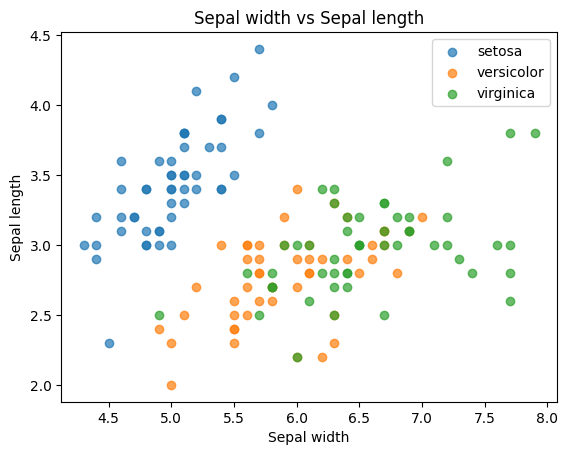

In [ ]:
for cls in range(3):
    mask = df['target'] == cls
    plt.scatter(df.loc[mask, 'sepal length (cm)'],
                df.loc[mask, 'sepal width (cm)'],
                label=iris.target_names[cls], alpha=0.7)
plt.title("Sepal width vs Sepal length")
plt.xlabel("Sepal width")
plt.ylabel("Sepal length")
plt.legend()
plt.show()

#vidimo da podaci nisu linearno separabilni

In [17]:
X = df.drop(columns='target')
y=df['target']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit samo na train!
X_test  = scaler.transform(X_test)       # transform na test istim scalerom

print('Veličina skupa za treniranje:', X_train.shape)
print('Veličina skupa za testiranje:', X_test.shape)
vk=SVC(kernel='linear')
vk.fit(X_train,y_train)
y_pred=vk.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print(f'Točnost na testnom skupu: {acc:.4f} ({acc*100}%)')

Veličina skupa za treniranje: (120, 4)
Veličina skupa za testiranje: (30, 4)
Točnost na testnom skupu: 0.9667 (96.66666666666667%)


In [20]:
#matrica zabune
cm=confusion_matrix(y_test,y_pred)
print(f"Matrica zabune\n")
print(cm)

Matrica zabune

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


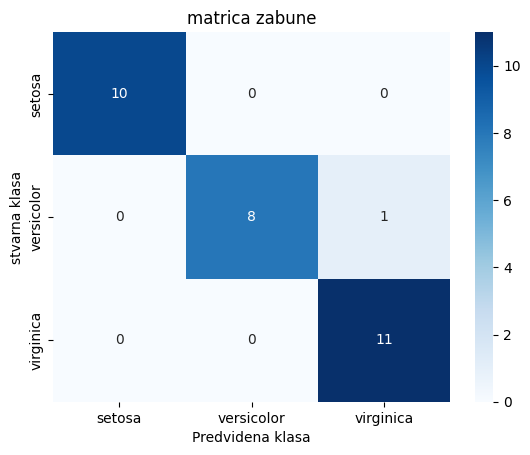

In [28]:
sbn.heatmap(cm,annot=True, cmap='Blues',xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("matrica zabune")
plt.ylabel("stvarna klasa")
plt.xlabel("Predvidena klasa")
plt.show()

In [29]:
class MyOvOClassifier:
    def __init__(self):
        self.classifiers = {}  # (klasa_i, klasa_j) -> trenirani model
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        k = len(self.classes_)

        # Treniramo k*(k-1)/2 binarnih klasifikatora
        for i in range(k):
            for j in range(i + 1, k):
                cls_i = self.classes_[i]
                cls_j = self.classes_[j]

                # Uzimamo samo podatke ta dva para klasa
                mask = (y == cls_i) | (y == cls_j)
                X_pair = X[mask]
                y_pair = y[mask]

                clf = SVC(kernel='linear', random_state=42)
                clf.fit(X_pair, y_pair)
                self.classifiers[(cls_i, cls_j)] = clf

        return self

    def predict(self, X):
        # Za svaki uzorak, svaki klasifikator glasuje
        m = X.shape[0]
        votes = np.zeros((m, len(self.classes_)), dtype=int)

        for (cls_i, cls_j), clf in self.classifiers.items():
            preds = clf.predict(X)
            for idx in range(m):
                if preds[idx] == cls_i:
                    votes[idx, cls_i] += 1
                else:
                    votes[idx, cls_j] += 1

        # Klasa s najviše glasova pobjeđuje
        return self.classes_[np.argmax(votes, axis=1)]

Točnost vlastite OvO implementacije: 0.9667 (96.7%)

Matrica zabune:


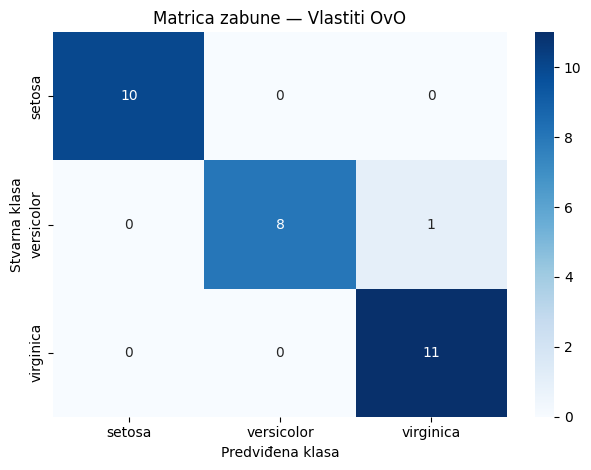

In [30]:
# Treniranje vlastite OvO implementacije
my_ovo = MyOvOClassifier()
my_ovo.fit(X_train, y_train)

# Predikcija i evaluacija
y_pred_ovo = my_ovo.predict(X_test)
acc_ovo = accuracy_score(y_test, y_pred_ovo)
print(f'Točnost vlastite OvO implementacije: {acc_ovo:.4f} ({acc_ovo*100:.1f}%)')

cm_ovo = confusion_matrix(y_test, y_pred_ovo)
print('\nMatrica zabune:')
sbn.heatmap(cm_ovo, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Matrica zabune — Vlastiti OvO')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.tight_layout()
plt.show()

Točnost sklearn OvO:   0.9667 (96.7%)


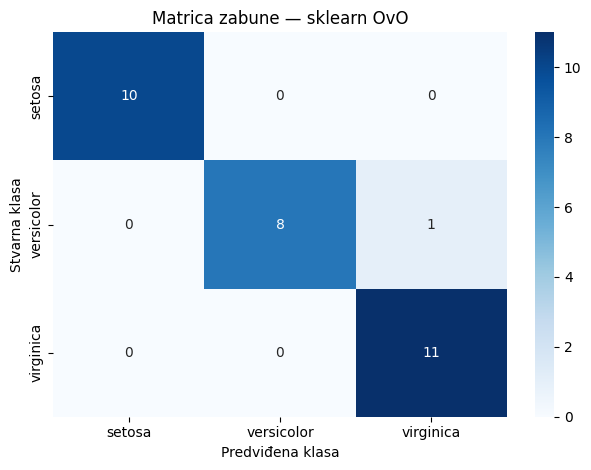

In [31]:
# 2.4.1 OneVsOneClassifier iz sklearn
ovo_sklearn = OneVsOneClassifier(SVC(kernel='linear', random_state=42))
ovo_sklearn.fit(X_train, y_train)
y_pred_ovo_sk = ovo_sklearn.predict(X_test)
acc_ovo_sk = accuracy_score(y_test, y_pred_ovo_sk)
print(f'Točnost sklearn OvO:   {acc_ovo_sk:.4f} ({acc_ovo_sk*100:.1f}%)')

cm_ovo_sk = confusion_matrix(y_test, y_pred_ovo_sk)
sbn.heatmap(cm_ovo_sk, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Matrica zabune — sklearn OvO')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.tight_layout()
plt.show()

In [32]:
# 2.4.2 OneVsRestClassifier
ovr_sklearn = OneVsRestClassifier(SVC(kernel='linear', random_state=42))
ovr_sklearn.fit(X_train, y_train)
y_pred_ovr = ovr_sklearn.predict(X_test)
acc_ovr = accuracy_score(y_test, y_pred_ovr)
print(f'Točnost sklearn OvR:   {acc_ovr:.4f} ({acc_ovr*100:.1f}%)')

# Usporedba svih pristupa
print('\n=== Usporedba točnosti ===')
print(f'SVC direktno:          {acc:.4f}')
print(f'Vlastiti OvO:          {acc_ovo:.4f}')
print(f'sklearn OvO:           {acc_ovo_sk:.4f}')
print(f'sklearn OvR:           {acc_ovr:.4f}')

Točnost sklearn OvR:   0.9667 (96.7%)

=== Usporedba točnosti ===
SVC direktno:          0.9667
Vlastiti OvO:          0.9667
sklearn OvO:           0.9667
sklearn OvR:           0.9667


In [33]:
print('OvO brzina treniranja:')

OvO brzina treniranja:


In [34]:
%%timeit
ovo_sklearn.fit(X_train,y_train)

4.11 ms ± 19.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [37]:
%%timeit
ovr_sklearn.fit(X_train,y_train)

5.74 ms ± 73.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
